In [1]:
import os, json
import cv2
import numpy as np
from import_db import load_vt_model, VocabNode, VocabTree, InvertedIndex, VocabTreeDB
from plot_benchmark import plot_benchmark

In [ ]:
# ---------- Parameters ----------
GROUND_TRUTH   = "ground_truth.json"
QUERY_RANGE    = range(1, 10+1)     # 1..10
NFEATURES      = 1500

TOPK_RETRIEVE  = 50                 # initial base candidates
TOPK_REPORT    = 10                 # after SV re-ranking, report top-10

INLIER_THRESH  = 0.05               # filter out weak spatial matches (tweak if needed)
RATIO_THRESH   = 0.75               # Lowe ratio for SV matching step
SV_CAP         = 1000
SV_LAMBDA      = 0.1
SV_OUTLIER_TOLERANCE = 3.0

In [3]:
# ---------- Feature Extraction ----------
def extract_sift(gray_img, nfeatures=500):
    sift = cv2.SIFT_create(nfeatures=nfeatures)
    kps, desc = sift.detectAndCompute(gray_img, None)
    if desc is None:
        return np.empty((0,128), np.float32), []
    return desc.astype(np.float32), kps
def to_rootsift(desc, eps=1e-12, l2_after=True):
    """
    Convert SIFT -> RootSIFT (Arandjelović & Zisserman, 2012).
    Steps: L1-normalize, then sqrt. Optionally L2-normalize after sqrt.
    desc: (N,128) float32
    """
    if desc is None or len(desc) == 0:
        return np.empty((0,128), np.float32)
    # L1-normalize
    desc /= (np.sum(desc, axis=1, keepdims=True) + eps)
    # element-wise sqrt
    desc = np.sqrt(desc, dtype=np.float32)
    if l2_after:
        # optional: stabilize numerics
        norms = np.linalg.norm(desc, axis=1, keepdims=True) + eps
        desc /= norms
    return desc.astype(np.float32)


In [4]:
db = load_vt_model("vocab_db/476imgs-2000descriptors-10k-4l-min_cluster100-max_iter100")

[load_vt_model] Loaded from: vocab_db/476imgs-2000descriptors-10k-4l-min_cluster100-max_iter100 | docs: 476 | leaves: 9856


In [8]:
def precision_recall_at_k(preds, gt_set, k):
    """Return (precision@k, recall@k)."""
    if k <= 0: return 0.0, 0.0
    p = preds[:k]
    hits = sum(1 for x in p if x in gt_set)
    prec = hits / len(p) if p else 0.0
    rec  = hits / len(gt_set) if gt_set else 0.0
    return prec, rec

def average_precision(preds, gt_set):
    """area under the precision recall curve via discrete ranks"""
    if not gt_set:
        return 0.0
    hits = 0
    precisions = []
    for i, x in enumerate(preds, start=1):
        if x in gt_set:
            hits += 1
            precisions.append(hits / i)
    if not precisions:
        return 0.0
    # divide by |GT| (or by number of relevant in the list). Using |GT| is standard.
    return sum(precisions) / len(gt_set)

def mean_reciprocal_rank(preds, gt_set):
    """Sensitive only to the first hit. A top-1 hit gives 1.0; a first hit at rank 5 gives 0.2"""
    for i, x in enumerate(preds, start=1):
        if x in gt_set:
            return 1.0 / i
    return 0.0

def run_one_query(db, qpath):
    img = cv2.imread(qpath, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Failed to read {qpath}")
    q_descs, q_kps = extract_sift(img, nfeatures=NFEATURES)
    q_descs = to_rootsift(q_descs)

    # 1) Baseline retrieval
    cands = db.query(q_descs, topk=TOPK_RETRIEVE)  # expected [(img_id, base_score), ...]
    # 2) Spatial verification & rerank
    reranked = db.spatial_verify(
        q_descs, q_kps, cands,
        ratio_thresh=RATIO_THRESH, cap=SV_CAP, lam=SV_LAMBDA, outlier_tolerance=SV_OUTLIER_TOLERANCE
    )  # expected [(img_id, final_score, inliers, inlier_ratio), ...]

    # 3) Filter by inlier ratio and take top-K
    reranked = [t for t in reranked if (len(t) >= 4 and t[3] !=0 and t[3] >= INLIER_THRESH)]
    reranked = reranked[:TOPK_REPORT]

    # Return compact structures for benchmarking/printing
    reranked = [(img, float(score), float(inl), float(inlier_ratio)) for (img, score, inl, inlier_ratio) in reranked]
    return cands, reranked


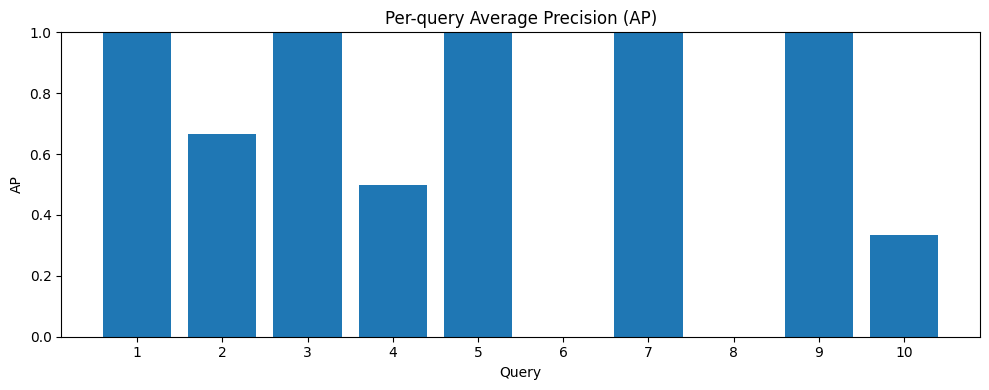

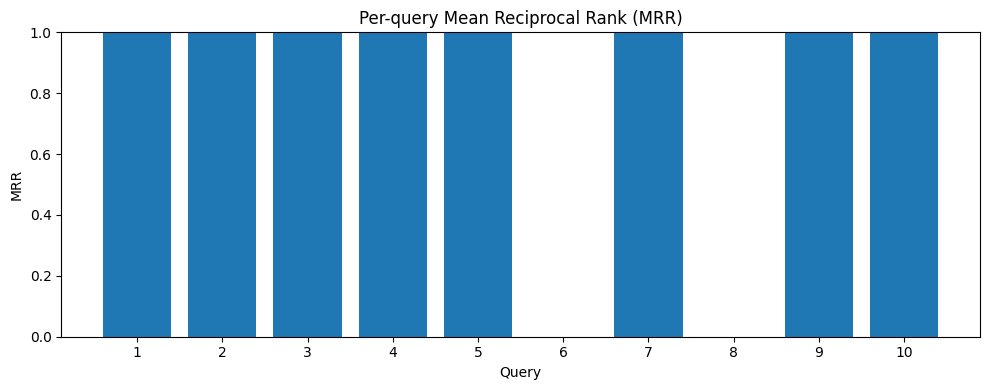

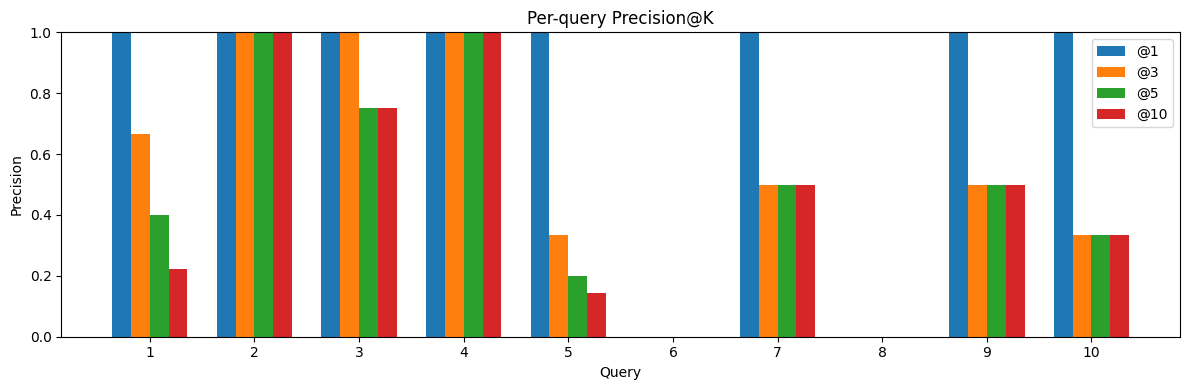

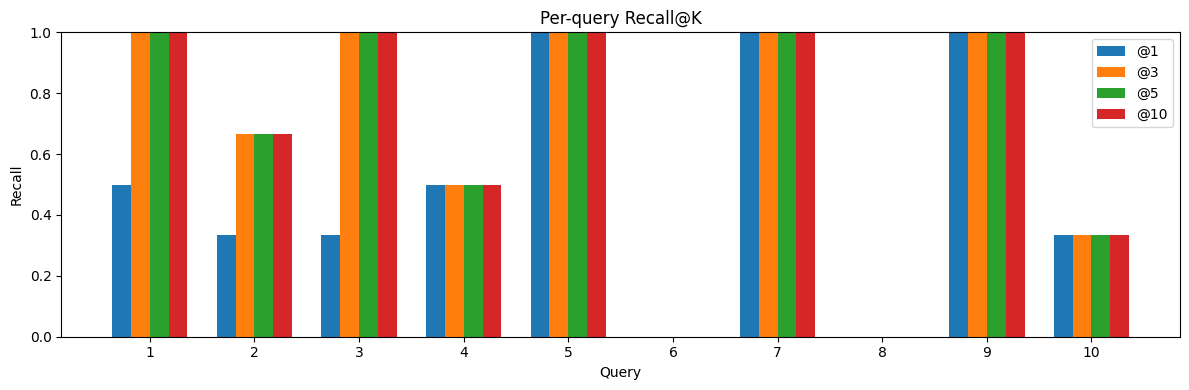

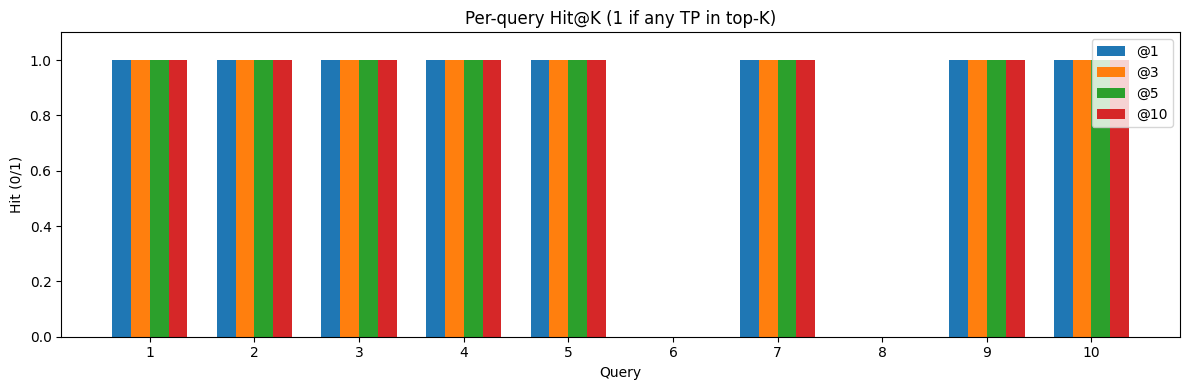

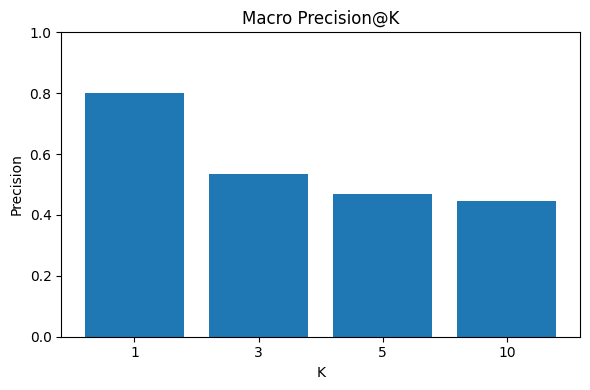

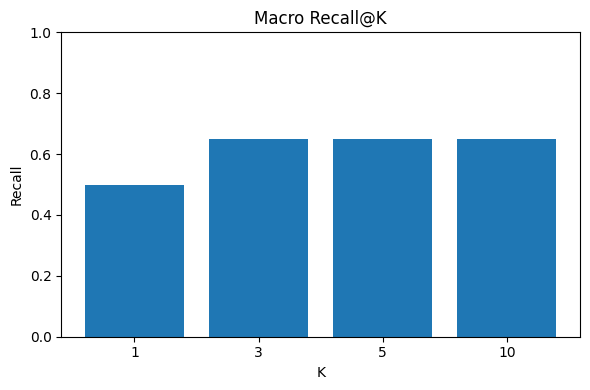

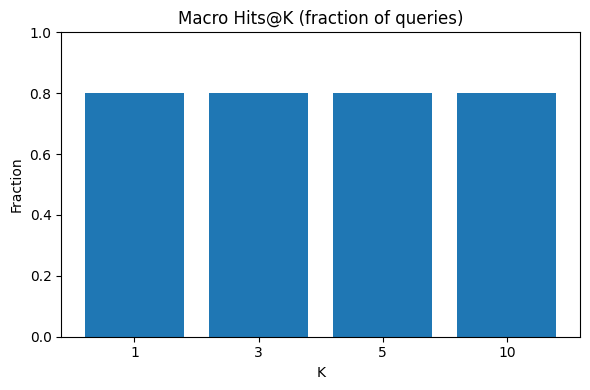

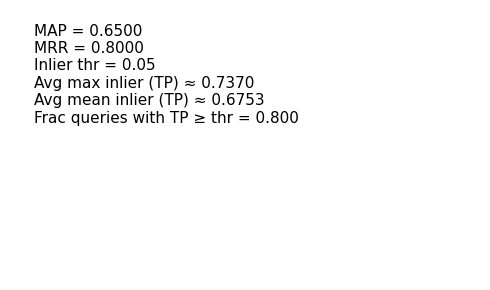

In [10]:
def main():
    with open(GROUND_TRUTH, "r", encoding="utf-8") as f:
        gt = json.load(f)

    # Hold per-query results
    per_query = []   # list of dicts

    # Aggregate metrics
    ks = [1, 3, 5, 10]
    agg_hits = {k: 0 for k in ks}
    agg_prec = {k: 0.0 for k in ks}
    agg_rec  = {k: 0.0 for k in ks}
    agg_ap   = 0.0
    agg_mrr  = 0.0

    # Side-note inlier stats
    max_inlier_ratio_tp = []   # per query: max inlier_ratio among true positives in final list (0 if none)
    mean_inlier_ratio_tp = []  # per query: mean inlier_ratio among true positives (0 if none)
    confident_tp_queries = 0   # queries where any TP has inlier_ratio >= INLIER_THRESH

    for i in QUERY_RANGE:
        qname = f"{i}.png"
        qpath = os.path.join(STAMPS_DIR, qname)
        cands, reranked_full = run_one_query(db, qpath)

        # Prediction list (ids only) after SV+filter
        preds_ids = [pid for (pid, _score, _inl,  _r) in reranked_full]
        gt_ids = set(gt.get(qname, []))  # ground truth list -> set

        # Compute metrics
        ap = average_precision(preds_ids, gt_ids)
        mrr = mean_reciprocal_rank(preds_ids, gt_ids)
        agg_ap  += ap
        agg_mrr += mrr
        perq = {
            "query": qname,
            "preds_top10": reranked_full,
            "AP": ap,
            "MRR": mrr
        }
        for k in ks:
            prec_k, rec_k = precision_recall_at_k(preds_ids, gt_ids, k)
            agg_prec[k] += prec_k
            agg_rec[k]  += rec_k
            # Hits@K means at least one correct in top-K
            hits_k = 1 if any(x in gt_ids for x in preds_ids[:k]) else 0
            agg_hits[k] += hits_k
            perq[f"Precision@{k}"] = prec_k
            perq[f"Recall@{k}"]    = rec_k
            perq[f"Hit@{k}"]       = hits_k

        # Side-note: inlier ratio stats among the true positives in the final list
        tp_inlier_ratios = [float(inlr) for (pid, _s, _inl, inlr) in reranked_full if pid in gt_ids]
        if tp_inlier_ratios:
            max_inlier_ratio_tp.append(max(tp_inlier_ratios))
            mean_inlier_ratio_tp.append(float(np.mean(tp_inlier_ratios)))
            if max(tp_inlier_ratios) >= INLIER_THRESH:
                confident_tp_queries += 1
        else:
            max_inlier_ratio_tp.append(0.0)
            mean_inlier_ratio_tp.append(0.0)

        per_query.append(perq)

    nQ = len(QUERY_RANGE)
    # Macro averages
    macro = {
        "MAP": agg_ap / nQ if nQ else 0.0,
        "MRR": agg_mrr / nQ if nQ else 0.0,
        "Precision@K": {k: (agg_prec[k] / nQ if nQ else 0.0) for k in ks},
        "Recall@K":    {k: (agg_rec[k]  / nQ if nQ else 0.0) for k in ks},
        "Hits@K":      {k: (agg_hits[k] / nQ if nQ else 0.0) for k in ks},  # fraction of queries with at least 1 correct in top-K
    }

    # Side-note benchmark based on inlier ratio
    side_note = {
        "inlier_ratio_threshold": INLIER_THRESH,
        "avg_max_inlier_ratio_TP": float(np.mean(max_inlier_ratio_tp)) if nQ else 0.0,
        "avg_mean_inlier_ratio_TP": float(np.mean(mean_inlier_ratio_tp)) if nQ else 0.0,
        "fraction_queries_with_confident_TP": confident_tp_queries / nQ if nQ else 0.0,
    }

    os.makedirs("benchmark", exist_ok=True)
    plot_benchmark(per_query, macro, side_note, output_dir="benchmark/476imgs-2000descriptors-10k-4l-min_cluster100-max_iter100")

if __name__ == "__main__":
    main()
